# Classification validation & performance:

In [1]:
import pandas as pd
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, cohen_kappa_score, mean_absolute_error
import warnings

In [2]:
# --- CONFIGURATION ---
EXAMPLES = False  # True if sentiment was executed including reasoning
REASONING = True  # True if sentiment was executed including reasoning
CONFIDENCE = False  # True if sentiment was executed including confidence scores
ROLE_NR = 1         # Role number for the system prompt with which sentiment was executed
MODEL = "Gem2.5f"   # Model ID for the model with which sentiment was executed
MULTISTAGE = 1  # Stage 1 is the base

# --- FILES ---
PREDICTIONS_FILE = f"PoC sentiment{f"_multi{MULTISTAGE}" if MULTISTAGE in (2, 3) else ""}_{MODEL}_role{ROLE_NR}{"_examples" if EXAMPLES else ""}{"_reasoning" if REASONING else ""}{"_confidence" if CONFIDENCE else ""}.csv"
GROUND_TRUTH_FILE = "PoC senti ground truth.csv"  # Manually classified csv
OUTPUT_METRICS_CSV = f"PoC senti validation{f"_multi{MULTISTAGE}" if MULTISTAGE in (2, 3) else ""}_{MODEL}_role{ROLE_NR}{"_examples" if EXAMPLES else ""}{"_reasoning" if REASONING else ""}{"_confidence" if CONFIDENCE else ""}.csv"
OUTPUT_VISUALIZATION = f"PoC senti confusion matrices{f"_multi{MULTISTAGE}" if MULTISTAGE in (2, 3) else ""}_{MODEL}_role{ROLE_NR}{"_examples" if EXAMPLES else ""}{"_reasoning" if REASONING else ""}{"_confidence" if CONFIDENCE else ""}.png"

SENTIMENT_LABELS = ["1", "0", "-1", "N/A"]


--- SENTIMENT VALIDATION: Gem2.5f ---
Accuracy:   0.8500
F1 Macro:   0.3701
MAE:        0.0000 (Lower is better, ignores N/A)
Kappa:      0.5000
Results saved to PoC senti validation_Gem2.5f_role1_reasoning.csv


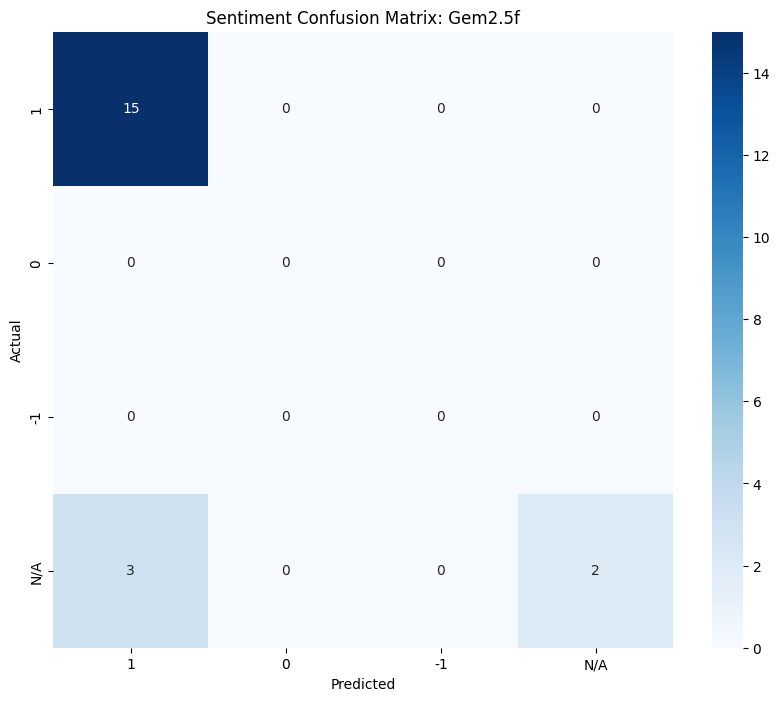

In [3]:
# Main script

def load_and_prepare_data():
    """Loads the files and aligns them using the 'Link' column."""
    if not os.path.exists(PREDICTIONS_FILE) or not os.path.exists(GROUND_TRUTH_FILE):
        print(f"ERROR: One of the input files is missing: {PREDICTIONS_FILE} or {GROUND_TRUTH_FILE}")
        sys.exit(1)

    df_pred = pd.read_csv(PREDICTIONS_FILE)
    df_true = pd.read_csv(GROUND_TRUTH_FILE)

    # Clean column names to avoid whitespace issues
    df_pred.columns = df_pred.columns.str.strip()
    df_true.columns = df_true.columns.str.strip()

    # Align data by sorting by Link
    df_pred = df_pred.sort_values(by="Link").reset_index(drop=True)
    df_true = df_true.sort_values(by="Link").reset_index(drop=True)

    # Align on Link
    combined = pd.merge(df_true[['Link', 'sentiment']], 
                        df_pred[['Link', 'sentiment']], 
                        on="Link", suffixes=('_true', '_pred'))
    return combined

def clean_label(val):
    """Makes sure values like 1, 1.0, '1' are all stored as string '1'."""
    if pd.isna(val): return "N/A"
    s = str(val).strip().split('.')[0]
    return s if s in SENTIMENT_LABELS else "N/A"

def main():

    warnings.filterwarnings("ignore")
    data = load_and_prepare_data()
        
    # Data cleaning
    y_true = data['sentiment_true'].apply(clean_label)
    y_pred = data['sentiment_pred'].apply(clean_label)

    # 1. Base Metrics (Multi-class)
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', labels=SENTIMENT_LABELS)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', labels=SENTIMENT_LABELS)
    kappa = cohen_kappa_score(y_true, y_pred, labels=SENTIMENT_LABELS)

    # 2. Mean Absolute Error (MAE)
    # Ignores N/A values
    numeric_mask = (y_true != "N/A") & (y_pred != "N/A")
    if numeric_mask.any():
        mae = mean_absolute_error(
            y_true[numeric_mask].astype(int), 
            y_pred[numeric_mask].astype(int)
        )
    else:
        mae = None

    # 3. Store results
    results = {
        "Model": MODEL,
        "Total_Posts": len(y_true),
        "Accuracy": acc,
        "F1_Macro": f1_macro,
        "F1_Weighted": f1_weighted,
        "Cohen_Kappa": kappa,
        "MAE_Numeric": mae,
        "N/A_Count_True": sum(y_true == "N/A"),
        "N/A_Count_Pred": sum(y_pred == "N/A")
    }
    
    pd.DataFrame([results]).to_csv(OUTPUT_METRICS_CSV, index=False, encoding='utf-8-sig')

    # 4. Visualization (confusion matrix)
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred, labels=SENTIMENT_LABELS)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=SENTIMENT_LABELS, 
                yticklabels=SENTIMENT_LABELS)
    
    plt.title(f"Sentiment Confusion Matrix: {MODEL}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(OUTPUT_VISUALIZATION)

    # Console Output
    print(f"\n--- SENTIMENT VALIDATION: {MODEL} ---")
    print(f"Accuracy:   {acc:.4f}")
    print(f"F1 Macro:   {f1_macro:.4f}")
    print(f"MAE:        {mae:.4f} (Lower is better, ignores N/A)")
    print(f"Kappa:      {kappa:.4f}")
    print(f"Results saved to {OUTPUT_METRICS_CSV}")

if __name__ == "__main__":
    main()

# Model comparison

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd
import os

Found 3 validation files. Extracting metrics...

--- PERFORMANCE RANKING (By F1 Macro) ---
                                       Model  Accuracy  F1 Macro  MAE
PoC senti validation_Gem2.5f_role3_reasoning      0.90  0.421875  0.0
PoC senti validation_Gem2.5f_role1_reasoning      0.85  0.370130  0.0
   PoC senti validation_GPT5_role1_reasoning      0.80  0.303922  0.0

Comparison graph saved as: senti_model_performance_comparison.png


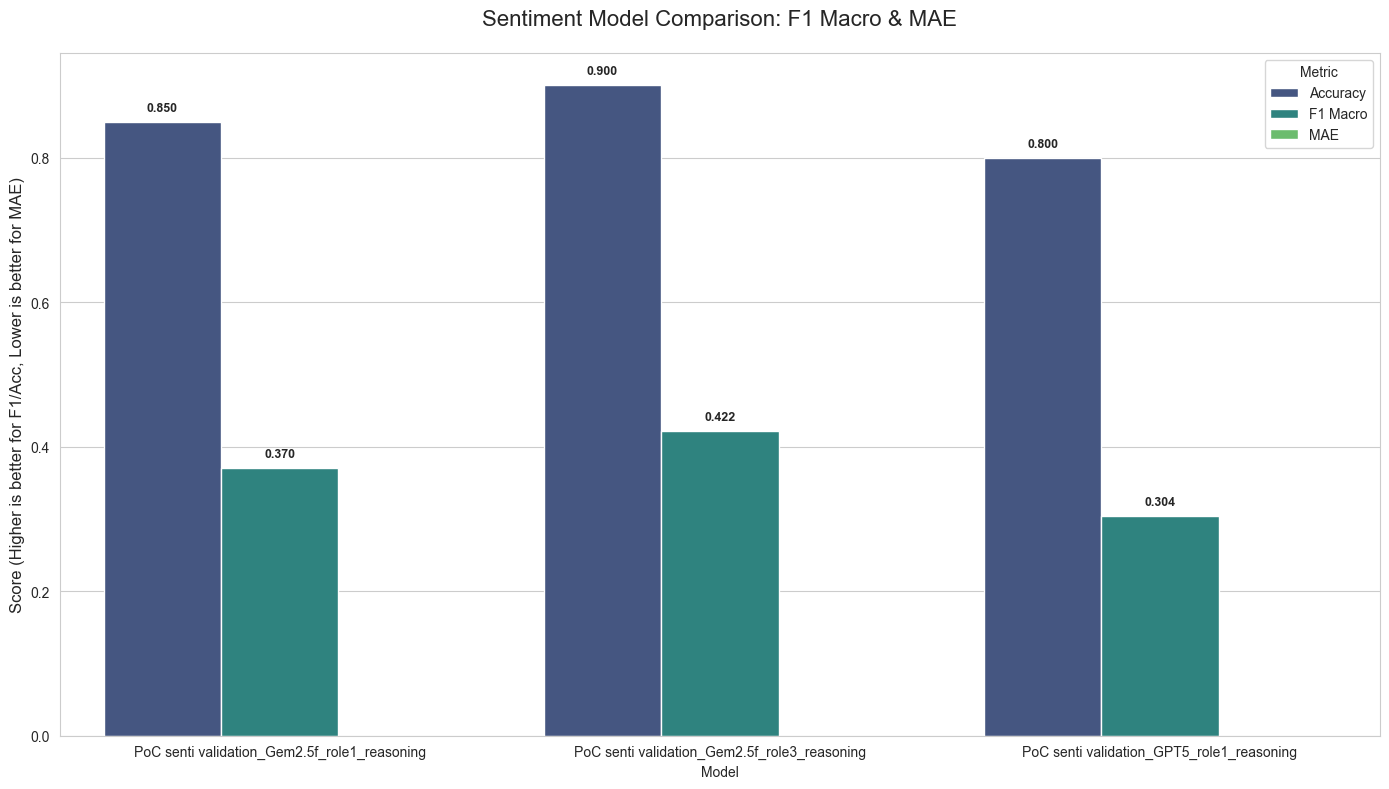

In [5]:
# --- CONFIGURATION ---
# The script will look for files matching this pattern in the current directory
FILE_PATTERN = r"PoC senti validation.*\.csv"
COMPARISON_OUTPUT_IMAGE = "senti_model_performance_comparison.png"

def extract_global_metrics(filepath):
    """Extracts metrics from the sentiment validation CSV."""
    try:
        df = pd.read_csv(filepath)
        # Results are in the first row
        row = df.iloc[0]
        
        display_name = os.path.basename(filepath).replace(".csv", "").replace("PoC sentiment validation_", "")
        
        return {
            "Model": display_name,
            "Accuracy": row["Accuracy"],
            "F1 Macro": row["F1_Macro"],
            "MAE": row["MAE_Numeric"]
        }
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None
    
def main():
    # 1. Find all relevant files
    all_files = [f for f in os.listdir('.') if re.match(FILE_PATTERN, f)]
    
    if not all_files:
        print("No validation files found matching the pattern and filters.")
        return

    print(f"Found {len(all_files)} validation files. Extracting metrics...")

    # 3. Extract metrics
    comparison_data = []
    for file in all_files:
        metrics = extract_global_metrics(file)
        if metrics:
            comparison_data.append(metrics)

    if not comparison_data:
        print("No valid global metrics could be extracted.")
        return

    df_comp = pd.DataFrame(comparison_data)

    # 4. Determine the best model (using Macro F1 as the primary key)    
    print("\n--- PERFORMANCE RANKING (By F1 Macro) ---")
    print(df_comp.sort_values(by="F1 Macro", ascending=False).to_string(index=False))

    # 5. Visualization
    df_melted = df_comp.melt(id_vars="Model", var_name="Metric", value_name="Score")

    plt.figure(figsize=(14, 8))
    sns.set_style("whitegrid")
    
    # Palette
    ax = sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", palette="viridis")
    
    plt.title("Sentiment Model Comparison: F1 Macro & MAE", fontsize=16, pad=20)
    plt.ylabel("Score (Higher is better for F1/Acc, Lower is better for MAE)", fontsize=12)
    
    # Add values on top of bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.3f}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', 
                        xytext=(0, 10), 
                        textcoords='offset points',
                        fontsize=9,
                        fontweight='bold')

    plt.tight_layout()
    plt.savefig(COMPARISON_OUTPUT_IMAGE)
    print(f"\nComparison graph saved as: {COMPARISON_OUTPUT_IMAGE}")

if __name__ == "__main__":
    main()